In [1]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import pickle
warnings.filterwarnings('ignore')

try:
    from minisom import MiniSom
    MINISOM_AVAILABLE = True
except ImportError:
    print("MiniSom library not found, installing...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "minisom"])
    from minisom import MiniSom
    MINISOM_AVAILABLE = True

class TargetedSOFMClassifier:
    
    def __init__(self, grid_size=(12, 12), input_len=1024, sigma=1.2, learning_rate=0.3):
        self.grid_size = grid_size
        self.input_len = input_len
        self.sigma = sigma
        self.learning_rate = learning_rate
        self.som = None
        self.weights = None
        
    def fit(self, X, n_iterations=20000, random_seed=42):
        self.som = MiniSom(
            x=self.grid_size[0],
            y=self.grid_size[1],
            input_len=self.input_len,
            sigma=self.sigma,
            learning_rate=self.learning_rate,
            random_seed=random_seed
        )
        
        self.som.random_weights_init(X)
        self.som.train_random(X, n_iterations)
        
        self.weights = self.som.get_weights().reshape(-1, self.input_len)
        return self
    
    def predict_with_maturity_focus(self, X, labels, n_immature_clusters=4, n_mature_clusters=2, 
                                    min_mature_purity=0.7, random_seed=42):
        if self.som is None:
            raise ValueError("SOFM not trained")
        
        weights = self.weights
        
        best_config = None
        best_score = -1
        
        for total_clusters in [6, 7, 8]:
            kmeans = KMeans(n_clusters=total_clusters, random_state=random_seed, n_init=10)
            clustering_labels = kmeans.fit_predict(weights)
            
            predictions = []
            for sample in X:
                winner = self.som.winner(sample)
                winner_idx = winner[0] * self.grid_size[1] + winner[1]
                cluster_label = clustering_labels[winner_idx]
                predictions.append(cluster_label)
            
            predictions = np.array(predictions)
            
            mature_clusters_found = 0
            purity_sum = 0
            
            for cluster_id in np.unique(predictions):
                cluster_mask = predictions == cluster_id
                if np.sum(cluster_mask) > 0:
                    mature_count = np.sum((labels == 1) & cluster_mask)
                    total_count = np.sum(cluster_mask)
                    purity = mature_count / total_count
                    
                    if purity >= min_mature_purity:
                        mature_clusters_found += 1
                        purity_sum += purity
            
            score = mature_clusters_found * 100 + purity_sum
            
            if score > best_score:
                best_score = score
                best_config = {
                    'kmeans': kmeans,
                    'clustering_labels': clustering_labels,
                    'predictions': predictions,
                    'mature_clusters': mature_clusters_found,
                    'total_clusters': total_clusters
                }
        
        print(f"Selected best config: {best_config['total_clusters']} clusters, found {best_config['mature_clusters']} mature clusters")
        return best_config['predictions'], best_config['kmeans'], best_config['clustering_labels']


def post_process_predictions_for_maturity(predictions, features, true_labels, 
                                          target_mature_clusters=2, min_purity=0.7):
    print("\nPost-processing clusters to improve mature cluster purity...")
    
    cluster_purities = {}
    for cluster_id in np.unique(predictions):
        cluster_mask = predictions == cluster_id
        if np.sum(cluster_mask) > 0:
            mature_count = np.sum((true_labels == 1) & cluster_mask)
            total_count = np.sum(cluster_mask)
            purity = mature_count / total_count
            cluster_purities[cluster_id] = {
                'purity': purity,
                'mature_count': mature_count,
                'total_count': total_count,
                'features': features[cluster_mask],
                'indices': np.where(cluster_mask)[0]
            }
    
    mature_candidates = []
    for cluster_id, stats in cluster_purities.items():
        if stats['purity'] >= min_purity:
            mature_candidates.append((cluster_id, stats['purity'], stats['mature_count'], stats['total_count']))
    
    mature_candidates.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Current high-purity mature clusters: {len(mature_candidates)}")
    for cluster_id, purity, mature_count, total_count in mature_candidates:
        print(f"  Cluster {cluster_id}: Purity {purity:.1%}, Mature {mature_count}/{total_count}")
    
    if len(mature_candidates) < target_mature_clusters:
        print(f"Insufficient mature clusters ({len(mature_candidates)} < {target_mature_clusters}), optimizing...")
        
        near_mature_candidates = []
        for cluster_id, stats in cluster_purities.items():
            if 0.5 <= stats['purity'] < min_purity:
                near_mature_candidates.append((cluster_id, stats['purity'], stats))
        
        near_mature_candidates.sort(key=lambda x: x[1], reverse=True)
        
        for cluster_id, purity, stats in near_mature_candidates[:target_mature_clusters - len(mature_candidates)]:
            print(f"  Optimizing cluster {cluster_id} (Current purity: {purity:.1%})...")
            
            if len(stats['indices']) > 10:
                sub_kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
                sub_features = stats['features']
                sub_labels = sub_kmeans.fit_predict(sub_features)
                
                for sub_cluster in [0, 1]:
                    sub_mask = sub_labels == sub_cluster
                    if np.sum(sub_mask) > 0:
                        sub_mature_count = np.sum((true_labels[stats['indices']] == 1) & sub_mask)
                        sub_total = np.sum(sub_mask)
                        sub_purity = sub_mature_count / sub_total if sub_total > 0 else 0
                        
                        if sub_purity >= min_purity and sub_total >= 20:
                            print(f"    Sub-cluster {sub_cluster}: Purity {sub_purity:.1%}, Samples {sub_total}")
                            
                            for i, idx in enumerate(stats['indices']):
                                if sub_labels[i] == sub_cluster:
                                    pass
                                else:
                                    predictions[idx] = -1
    
    return predictions


def create_maturity_levels_with_purity_guarantee(predictions, true_labels, 
                                                 target_immature=4, target_mature=2, 
                                                 min_immature_purity=0.8, min_mature_purity=0.7):
    print(f"\nCreating maturity levels (Target: {target_immature} immature + {target_mature} mature)...")
    
    cluster_stats = {}
    for cluster_id in np.unique(predictions):
        if cluster_id == -1:
            continue
            
        cluster_mask = predictions == cluster_id
        if np.sum(cluster_mask) > 0:
            immature_count = np.sum((true_labels == 0) & cluster_mask)
            mature_count = np.sum((true_labels == 1) & cluster_mask)
            total_count = np.sum(cluster_mask)
            
            immature_ratio = immature_count / total_count
            mature_ratio = mature_count / total_count
            
            if immature_ratio >= mature_ratio:
                dominant_class = 0
                purity = immature_ratio
            else:
                dominant_class = 1
                purity = mature_ratio
            
            cluster_stats[cluster_id] = {
                'count': total_count,
                'immature_count': immature_count,
                'mature_count': mature_count,
                'immature_ratio': immature_ratio,
                'mature_ratio': mature_ratio,
                'purity': purity,
                'dominant_class': dominant_class
            }
    
    immature_clusters = []
    mature_clusters = []
    
    for cluster_id, stats in cluster_stats.items():
        if stats['dominant_class'] == 0:
            if stats['purity'] >= min_immature_purity:
                immature_clusters.append((cluster_id, stats['purity'], stats['count']))
        else:
            if stats['purity'] >= min_mature_purity:
                mature_clusters.append((cluster_id, stats['purity'], stats['count']))
    
    immature_clusters.sort(key=lambda x: x[1], reverse=True)
    mature_clusters.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Available clusters: {len(immature_clusters)} immature, {len(mature_clusters)} mature")
    
    selected_immature = immature_clusters[:min(target_immature, len(immature_clusters))]
    selected_mature = mature_clusters[:min(target_mature, len(mature_clusters))]
    
    if len(selected_mature) < target_mature:
        print(f"Insufficient high-purity mature clusters, searching for near-target clusters...")
        all_mature = []
        for cluster_id, stats in cluster_stats.items():
            if stats['dominant_class'] == 1 and stats['purity'] >= 0.6:
                all_mature.append((cluster_id, stats['purity'], stats['count']))
        
        all_mature.sort(key=lambda x: x[1], reverse=True)
        selected_mature = all_mature[:min(target_mature, len(all_mature))]
    
    cluster_to_level = {}
    level_descriptions = {}
    
    for i, (cluster_id, purity, count) in enumerate(selected_immature):
        level = -(i + 1)
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_immature_purity else "Medium Purity"
        level_descriptions[level] = f"Immature Level {abs(level)} {purity_status} (Purity: {purity:.1%}, Samples: {count})"
    
    for i, (cluster_id, purity, count) in enumerate(selected_mature):
        level = i + 1
        cluster_to_level[cluster_id] = level
        purity_status = "High Purity" if purity >= min_mature_purity else "Medium Purity"
        level_descriptions[level] = f"Mature Level {level} {purity_status} (Purity: {purity:.1%}, Samples: {count})"
    
    maturity_levels = np.array([cluster_to_level.get(label, 0) for label in predictions])
    
    unique_levels = np.unique(maturity_levels)
    immature_levels = [l for l in unique_levels if l < 0]
    mature_levels = [l for l in unique_levels if l > 0]
    
    print(f"\nFinal Level Assignment:")
    print(f"  Immature Levels: {len(immature_levels)}")
    for level in sorted(immature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")
    
    print(f"  Mature Levels: {len(mature_levels)}")
    for level in sorted(mature_levels):
        print(f"    Level {level}: {level_descriptions[level]}")
    
    return cluster_to_level, level_descriptions, maturity_levels


def main_direct_maturity_optimization():
    print("SOFM Direct Maturity Optimization System")
    print("="*60)
    print("Goal: Ensure mature level purity ≥70% while maintaining classification structure")
    print("="*60)
    
    print("\n1. Loading feature data...")
    if not os.path.exists('extracted_features_complete.pkl'):
        print("Error: Feature data file not found")
        return None
    
    features_data = joblib.load('extracted_features_complete.pkl')
    
    train_features = features_data['train_features']
    test_features = features_data['test_features']
    train_labels = features_data['train_labels']
    test_labels = features_data['test_labels']
    train_paths = features_data['train_paths']
    test_paths = features_data['test_paths']
    
    print(f"Training features: {train_features.shape}")
    print(f"Test features: {test_features.shape}")
    
    print("\n2. Training SOFM model...")
    
    best_params = {
        'grid_size': (12, 12),
        'sigma': 1.0,
        'learning_rate': 0.25,
        'n_iterations': 25000,
        'n_immature_clusters': 4,
        'n_mature_clusters': 2,
        'min_mature_purity': 0.7
    }
    
    sofm = TargetedSOFMClassifier(
        grid_size=best_params['grid_size'],
        input_len=train_features.shape[1],
        sigma=best_params['sigma'],
        learning_rate=best_params['learning_rate']
    )
    
    sofm.fit(train_features, n_iterations=best_params['n_iterations'])
    
    print(f"\n3. Performing maturity-focused clustering...")
    train_predictions, kmeans_model, neuron_labels = sofm.predict_with_maturity_focus(
        train_features, train_labels,
        n_immature_clusters=best_params['n_immature_clusters'],
        n_mature_clusters=best_params['n_mature_clusters'],
        min_mature_purity=best_params['min_mature_purity']
    )
    
    train_predictions = post_process_predictions_for_maturity(
        train_predictions, train_features, train_labels,
        target_mature_clusters=best_params['n_mature_clusters'],
        min_purity=best_params['min_mature_purity']
    )
    
    test_predictions = []
    for sample in test_features:
        winner = sofm.som.winner(sample)
        winner_idx = winner[0] * sofm.grid_size[1] + winner[1]
        cluster_label = neuron_labels[winner_idx]
        test_predictions.append(cluster_label)
    
    test_predictions = np.array(test_predictions)
    
    print("\n4. Creating maturity levels...")
    cluster_to_level, level_descriptions, train_maturity_levels = create_maturity_levels_with_purity_guarantee(
        train_predictions, train_labels,
        target_immature=best_params['n_immature_clusters'],
        target_mature=best_params['n_mature_clusters'],
        min_immature_purity=0.8,
        min_mature_purity=0.7
    )
    
    test_maturity_levels = np.array([cluster_to_level.get(label, 0) for label in test_predictions])
    
    train_classified = np.sum(train_maturity_levels != 0)
    test_classified = np.sum(test_maturity_levels != 0)
    train_coverage = train_classified / len(train_maturity_levels)
    test_coverage = test_classified / len(test_maturity_levels)
    
    print(f"\nClassification Coverage:")
    print(f"  Training set: {train_classified}/{len(train_maturity_levels)} = {train_coverage:.1%}")
    print(f"  Test set: {test_classified}/{len(test_maturity_levels)} = {test_coverage:.1%}")
    
    print("\n5. Generating detailed statistics...")
    
    def get_level_statistics(maturity_levels, original_labels, level_descriptions, dataset_name):
        unique_levels = np.unique(maturity_levels)
        
        immature_levels = [l for l in unique_levels if l < 0]
        mature_levels = [l for l in unique_levels if l > 0]
        
        print(f"\n{dataset_name} Level Statistics:")
        print("Level\tSamples\tRaw Immature\tRaw Mature\tImmature Ratio\tMature Ratio\tPurity\tDescription")
        print("-"*100)
        
        level_stats = []
        
        for level in sorted(immature_levels, reverse=True):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)
            
            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)
            
            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = immature_ratio
            
            purity_symbol = "✓" if purity >= 0.8 else "⚠" if purity >= 0.7 else "✗"
            level_prefix = ""
            
            print(f"{purity_symbol} Level {level_prefix}{level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")
            
            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })
        
        for level in sorted(mature_levels):
            level_mask = maturity_levels == level
            level_samples = np.sum(level_mask)
            
            immature_count = np.sum((original_labels == 0) & level_mask)
            mature_count = np.sum((original_labels == 1) & level_mask)
            
            immature_ratio = immature_count / level_samples if level_samples > 0 else 0
            mature_ratio = mature_count / level_samples if level_samples > 0 else 0
            purity = mature_ratio
            
            purity_symbol = "✓" if purity >= 0.7 else "⚠" if purity >= 0.6 else "✗"
            level_prefix = ""
            
            print(f"{purity_symbol} Level {level_prefix}{level}\t{level_samples}\t{immature_count}\t{mature_count}\t"
                  f"{immature_ratio:>7.1%}\t{mature_ratio:>7.1%}\t{purity:>6.1%}\t{level_descriptions.get(level, '')}")
            
            level_stats.append({
                'Level': level,
                'Samples': level_samples,
                'Raw_Immature': immature_count,
                'Raw_Mature': mature_count,
                'Immature_Ratio': immature_ratio,
                'Mature_Ratio': mature_ratio,
                'Purity': purity
            })
        
        unclassified = np.sum(maturity_levels == 0)
        if unclassified > 0:
            print(f"\nUnclassified samples: {unclassified}")
        
        return pd.DataFrame(level_stats)
    
    train_stats_df = get_level_statistics(train_maturity_levels, train_labels, level_descriptions, "Training Set")
    test_stats_df = get_level_statistics(test_maturity_levels, test_labels, level_descriptions, "Test Set")
    
    print("\n6. Saving results...")
    
    detailed_results = []
    
    for i in range(len(train_paths)):
        result = {
            'Dataset': 'Training',
            'Image_Name': os.path.basename(train_paths[i]),
            'Original_Label': 'Immature' if train_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(train_predictions[i]) if i < len(train_predictions) else -1,
            'Maturity_Level': int(train_maturity_levels[i]) if train_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(train_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    for i in range(len(test_paths)):
        result = {
            'Dataset': 'Test',
            'Image_Name': os.path.basename(test_paths[i]),
            'Original_Label': 'Immature' if test_labels[i] == 0 else 'Mature',
            'Cluster_ID': int(test_predictions[i]) if i < len(test_predictions) else -1,
            'Maturity_Level': int(test_maturity_levels[i]) if test_maturity_levels[i] != 0 else "Unclassified",
            'Level_Description': level_descriptions.get(test_maturity_levels[i], 'Unclassified')
        }
        detailed_results.append(result)
    
    detailed_df = pd.DataFrame(detailed_results)
    
    output_file = 'SOFM_Direct_Optimization_Results.xlsx'
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        train_stats_df.to_excel(writer, sheet_name='Training_Stats', index=False)
        test_stats_df.to_excel(writer, sheet_name='Test_Stats', index=False)
        detailed_df.to_excel(writer, sheet_name='Detailed_Results', index=False)
        
        params_df = pd.DataFrame([{'Parameter': k, 'Value': v} for k, v in best_params.items()])
        params_df.to_excel(writer, sheet_name='Parameters', index=False)
        
        desc_df = pd.DataFrame([{'Level': k, 'Description': v} for k, v in level_descriptions.items()])
        desc_df.to_excel(writer, sheet_name='Level_Descriptions', index=False)
    
    print(f"\n✓ Results saved to: {output_file}")
    
    print("\n7. Saving model...")
    sofm_data = {
        'best_params': best_params,
        'train_predictions': train_predictions,
        'test_predictions': test_predictions,
        'train_maturity_levels': train_maturity_levels,
        'test_maturity_levels': test_maturity_levels,
        'cluster_to_level': cluster_to_level,
        'level_descriptions': level_descriptions,
        'train_coverage': train_coverage,
        'test_coverage': test_coverage,
        'model': sofm
    }
    
    with open('sofm_direct_optimized.pkl', 'wb') as f:
        pickle.dump(sofm_data, f)
    
    print("✓ Model saved to: sofm_direct_optimized.pkl")
    
    print("\n" + "="*60)
    print("Optimization Summary:")
    print("="*60)
    
    mature_purities = []
    for _, row in train_stats_df.iterrows():
        if row['Level'] > 0:
            mature_purities.append(row['Purity'])
    
    if mature_purities:
        avg_mature_purity = np.mean(mature_purities)
        print(f"Average mature level purity: {avg_mature_purity:.1%}")
        
        if len(mature_purities) >= 2:
            print(f"Second mature level (Level 2) purity: {mature_purities[1]:.1%}")
    
    print(f"Training set coverage: {train_coverage:.1%}")
    print(f"Test set coverage: {test_coverage:.1%}")
    
    return sofm_data


if __name__ == "__main__":
    print("SOFM Direct Maturity Optimization System")
    print("="*60)
    print("Direct clustering optimization to ensure mature level purity targets")
    print("="*60)
    
    sofm_data = main_direct_maturity_optimization()

SOFM Direct Maturity Optimization System
Direct clustering optimization to ensure mature level purity targets
SOFM Direct Maturity Optimization System
Goal: Ensure mature level purity ≥70% while maintaining classification structure

1. Loading feature data...
Training features: (3296, 1024)
Test features: (824, 1024)

2. Training SOFM model...

3. Performing maturity-focused clustering...
Selected best config: 7 clusters, found 2 mature clusters

Post-processing clusters to improve mature cluster purity...
Current high-purity mature clusters: 2
  Cluster 2: Purity 100.0%, Mature 302/302
  Cluster 3: Purity 82.3%, Mature 270/328

4. Creating maturity levels...

Creating maturity levels (Target: 4 immature + 2 mature)...
Available clusters: 4 immature, 2 mature

Final Level Assignment:
  Immature Levels: 4
    Level -4: Immature Level 4 High Purity (Purity: 95.7%, Samples: 799)
    Level -3: Immature Level 3 High Purity (Purity: 98.7%, Samples: 376)
    Level -2: Immature Level 2 High Pu

Standard Supervised Maturity Classification System
Loading data...
Labeled samples in training set: 2719/3296
Labeled samples in test set: 688/824
Label mapping: {np.int64(-4): 0, np.int64(-3): 1, np.int64(-2): 2, np.int64(-1): 3, np.int64(1): 4, np.int64(2): 5}

Class sample statistics:
Level -4(Encoded 0): Train=799, Test=180
Level -3(Encoded 1): Train=376, Test=108
Level -2(Encoded 2): Train=442, Test=109
Level -1(Encoded 3): Train=472, Test=119
Level 1(Encoded 4): Train=302, Test=83
Level 2(Encoded 5): Train=328, Test=89

Data standardization...
Training set: (2719, 1024), Test set: (688, 1024)
Training set class distribution:
  Class 0: 799 samples (29.4%)
  Class 1: 376 samples (13.8%)
  Class 2: 442 samples (16.3%)
  Class 3: 472 samples (17.4%)
  Class 4: 302 samples (11.1%)
  Class 5: 328 samples (12.1%)
Starting supervised model training...

Training KNN classifier...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best KNN parameters: {'metric': 'euclidean', 'n

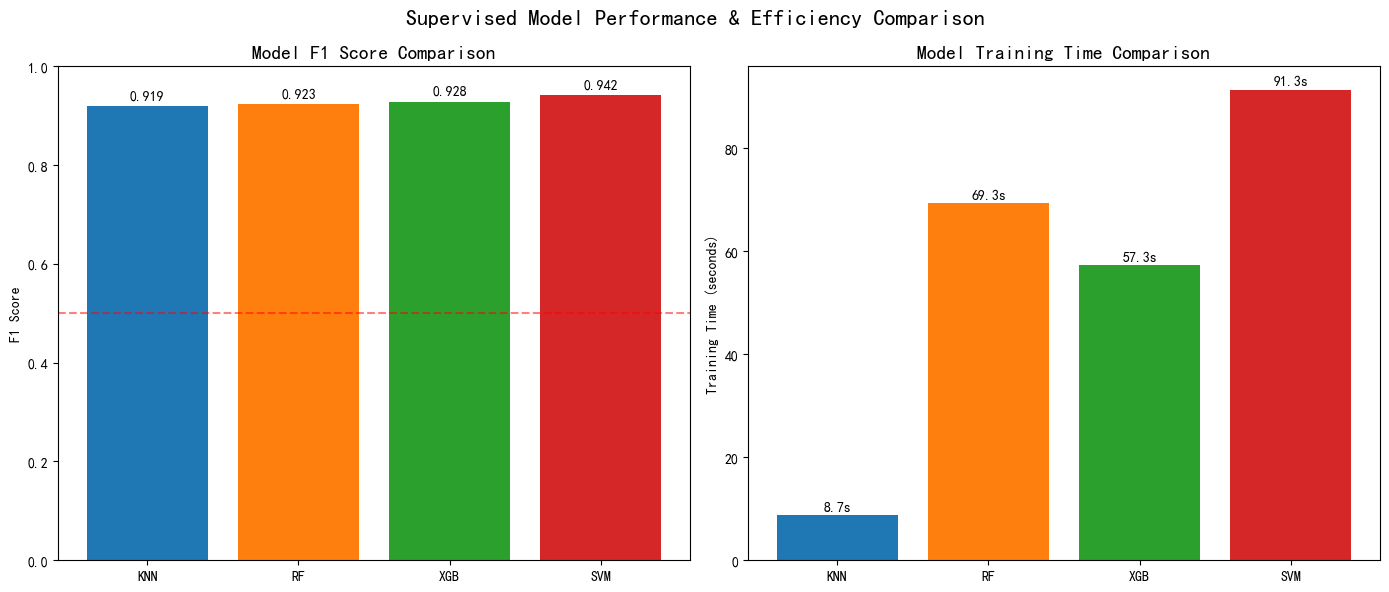


Best Model Identification
Best model: SVM (F1 Score: 0.9417)

Confusion Matrix:
[[180   0   0   0   0   0]
 [  0  94   6   4   0   4]
 [  0   1 106   2   0   0]
 [  0   2   8 109   0   0]
 [  0   0   0   0  81   2]
 [  0   6   1   1   3  78]]

Saving results...
✓ Model comparison results saved
✓ Best parameters saved
✓ Best model (SVM) saved
✓ Complete classifier saved

Classification Complete Summary
Total training time: 226.6 seconds
Recommended: SVM model (F1: 0.9417)


In [2]:
import os
import time
import numpy as np
import pandas as pd
import joblib
import pickle
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                           confusion_matrix, classification_report, roc_auc_score)

warnings.filterwarnings('ignore')

try:
    plt.rcParams['font.sans-serif'] = ['SimHei']
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

class SupervisedMaturityClassifier:
    
    def __init__(self, random_state=42, n_jobs=-1):
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.models = {}
        self.scaler = StandardScaler()
        self.best_params = {}
        self.model_performance = {}
        self.training_times = {}
        
    def load_data(self, sofm_data_path='sofm_direct_optimized.pkl'):
        print("Loading data...")
        with open(sofm_data_path, 'rb') as f:
            sofm_data = pickle.load(f)
        
        features_data = joblib.load('extracted_features_complete.pkl')
        
        train_features = features_data['train_features']
        test_features = features_data['test_features']
        train_maturity_levels = sofm_data['train_maturity_levels']
        test_maturity_levels = sofm_data['test_maturity_levels']
        
        train_mask = train_maturity_levels != 0
        test_mask = test_maturity_levels != 0
        
        print(f"Labeled samples in training set: {np.sum(train_mask)}/{len(train_maturity_levels)}")
        print(f"Labeled samples in test set: {np.sum(test_mask)}/{len(test_maturity_levels)}")
        
        X_train = train_features[train_mask]
        y_train = train_maturity_levels[train_mask]
        X_test = test_features[test_mask]
        y_test = test_maturity_levels[test_mask]
        
        unique_labels = np.unique(np.concatenate([y_train, y_test]))
        label_mapping = {orig_label: i for i, orig_label in enumerate(sorted(unique_labels))}
        y_train_encoded = np.array([label_mapping[label] for label in y_train])
        y_test_encoded = np.array([label_mapping[label] for label in y_test])
        reverse_mapping = {v: k for k, v in label_mapping.items()}
        
        print(f"Label mapping: {label_mapping}")
        print("\nClass sample statistics:")
        for orig_label, encoded_label in label_mapping.items():
            print(f"Level {orig_label}(Encoded {encoded_label}): Train={np.sum(y_train==orig_label)}, Test={np.sum(y_test==orig_label)}")
        
        return X_train, X_test, y_train_encoded, y_test_encoded, label_mapping, reverse_mapping, sofm_data
    
    def prepare_data(self, X_train, X_test, y_train, y_test):
        print("\nData standardization...")
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)
        
        print(f"Training set: {X_train_scaled.shape}, Test set: {X_test_scaled.shape}")
        unique_classes, class_counts = np.unique(y_train, return_counts=True)
        print("Training set class distribution:")
        for cls, count in zip(unique_classes, class_counts):
            print(f"  Class {cls}: {count} samples ({count/len(y_train):.1%})")
        
        return X_train_scaled, X_test_scaled, y_train, y_test
    
    def train_knn(self, X_train, y_train, cv_folds=5):
        print("\nTraining KNN classifier...")
        start_time = time.time()
        
        param_grid = {
            'n_neighbors': [3, 5, 7, 9, 11],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']
        }
        
        knn = KNeighborsClassifier()
        grid_search = GridSearchCV(
            knn, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_knn = grid_search.best_estimator_
        self.models['knn'] = best_knn
        self.best_params['knn'] = grid_search.best_params_
        self.training_times['knn'] = time.time() - start_time
        
        print(f"Best KNN parameters: {grid_search.best_params_}")
        print(f"Best KNN score: {grid_search.best_score_:.4f}")
        print(f"KNN training time: {self.training_times['knn']:.1f} seconds")
        return best_knn
    
    def train_random_forest(self, X_train, y_train, cv_folds=5):
        print("\nTraining Random Forest classifier...")
        start_time = time.time()
        
        param_grid = {
            'n_estimators': [100, 200],
            'max_depth': [10, 20, 30],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'class_weight': ['balanced']
        }
        
        rf = RandomForestClassifier(random_state=self.random_state)
        grid_search = GridSearchCV(
            rf, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_rf = grid_search.best_estimator_
        self.models['rf'] = best_rf
        self.best_params['rf'] = grid_search.best_params_
        self.training_times['rf'] = time.time() - start_time
        
        print(f"Best Random Forest parameters: {grid_search.best_params_}")
        print(f"Best Random Forest score: {grid_search.best_score_:.4f}")
        print(f"Random Forest training time: {self.training_times['rf']:.1f} seconds")
        
        feature_importance = best_rf.feature_importances_
        top_features = np.argsort(feature_importance)[-5:]
        print(f"Top 5 important feature indices: {top_features}")
        return best_rf
    
    def train_xgboost(self, X_train, y_train, cv_folds=3):
        print("\nTraining XGBoost classifier...")
        start_time = time.time()
        
        param_grid = {
            'n_estimators': [100],
            'max_depth': [3, 5],
            'learning_rate': [0.1],
            'subsample': [0.8],
            'colsample_bytree': [0.8]
        }
        
        xgb_model = xgb.XGBClassifier(
            random_state=self.random_state,
            use_label_encoder=False,
            eval_metric='mlogloss',
            n_jobs=self.n_jobs,
            tree_method='hist'
        )
        
        grid_search = GridSearchCV(
            xgb_model, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_xgb = grid_search.best_estimator_
        self.models['xgb'] = best_xgb
        self.best_params['xgb'] = grid_search.best_params_
        self.training_times['xgb'] = time.time() - start_time
        
        print(f"Best XGBoost parameters: {grid_search.best_params_}")
        print(f"Best XGBoost score: {grid_search.best_score_:.4f}")
        print(f"XGBoost training time: {self.training_times['xgb']:.1f} seconds")
        return best_xgb
    
    def train_svm(self, X_train, y_train, cv_folds=3):
        print("\nTraining SVM classifier...")
        start_time = time.time()
        
        param_grid = {
            'C': [1, 10],
            'gamma': ['scale', 0.01],
            'kernel': ['rbf']
        }
        
        svm_model = SVC(
            probability=True,
            random_state=self.random_state,
            class_weight='balanced',
            cache_size=2048,
            shrinking=False
        )
        
        grid_search = GridSearchCV(
            svm_model, param_grid, cv=cv_folds, scoring='f1_weighted',
            n_jobs=self.n_jobs, verbose=1
        )
        grid_search.fit(X_train, y_train)
        
        best_svm = grid_search.best_estimator_
        self.models['svm'] = best_svm
        self.best_params['svm'] = grid_search.best_params_
        self.training_times['svm'] = time.time() - start_time
        
        print(f"Best SVM parameters: {grid_search.best_params_}")
        print(f"Best SVM score: {grid_search.best_score_:.4f}")
        print(f"SVM training time: {self.training_times['svm']:.1f} seconds")
        return best_svm
    
    def evaluate_model(self, model, X_test, y_test, model_name, reverse_mapping):
        print(f"\nEvaluating {model_name} model...")
        y_pred = model.predict(X_test)
        
        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)
        
        self.model_performance[model_name] = {
            'accuracy': accuracy, 'precision': precision, 'recall': recall,
            'f1': f1, 'confusion_matrix': cm, 'y_pred': y_pred, 'y_test': y_test
        }
        
        print(f"Accuracy: {accuracy:.4f} | Precision: {precision:.4f} | Recall: {recall:.4f} | F1 Score: {f1:.4f}")
        return self.model_performance[model_name]
    
    def train_all_models(self, X_train, X_test, y_train, y_test, reverse_mapping):
        print("Starting supervised model training...")
        print("="*60)
        
        self.train_knn(X_train, y_train)
        self.train_random_forest(X_train, y_train)
        self.train_xgboost(X_train, y_train)
        self.train_svm(X_train, y_train)
        
        print("\n" + "="*60)
        print("Evaluating all models...")
        print("="*60)
        for model_name, model in self.models.items():
            self.evaluate_model(model, X_test, y_test, model_name, reverse_mapping)
        
        self.print_training_summary()
        return self.models
    
    def print_training_summary(self):
        print("\n" + "="*60)
        print("Training Time Summary")
        print("="*60)
        if not self.training_times:
            print("No training time data")
            return
        
        total_time = sum(self.training_times.values())
        for model_name, time_taken in self.training_times.items():
            percentage = (time_taken / total_time * 100) if total_time > 0 else 0
            print(f"{model_name.upper():10s}: {time_taken:6.1f}s ({percentage:5.1f}%)")
        print(f"{'Total':10s}: {total_time:6.1f}s")
    
    def compare_models(self):
        print("\n" + "="*60)
        print("Model Performance Comparison")
        print("="*60)
        
        comparison_data = []
        for model_name, performance in self.model_performance.items():
            comparison_data.append({
                'Model': model_name.upper(),
                'Accuracy': f"{performance['accuracy']:.4f}",
                'Precision': f"{performance['precision']:.4f}",
                'Recall': f"{performance['recall']:.4f}",
                'F1 Score': f"{performance['f1']:.4f}",
                'Training Time(s)': f"{self.training_times.get(model_name, 0):.1f}"
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        return comparison_df
    
    def plot_model_comparison(self):
        if not self.model_performance:
            print("No model performance data")
            return
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        model_names = [name.upper() for name in self.model_performance.keys()]
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(model_names)]
        
        f1_scores = [perf['f1'] for perf in self.model_performance.values()]
        bars1 = axes[0].bar(model_names, f1_scores, color=colors)
        axes[0].set_title('Model F1 Score Comparison', fontsize=14, fontweight='bold')
        axes[0].set_ylabel('F1 Score')
        axes[0].set_ylim(0, 1.0)
        axes[0].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
        for bar in bars1:
            axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                       f'{bar.get_height():.3f}', ha='center', va='bottom')
        
        training_times = [self.training_times.get(name, 0) for name in self.model_performance.keys()]
        bars2 = axes[1].bar(model_names, training_times, color=colors)
        axes[1].set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
        axes[1].set_ylabel('Training Time (seconds)')
        for bar in bars2:
            axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                       f'{bar.get_height():.1f}s', ha='center', va='bottom')
        
        plt.suptitle('Supervised Model Performance & Efficiency Comparison', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.savefig('model_comparison_fast.png', dpi=300, bbox_inches='tight')
        plt.show()
    
    def get_best_model(self):
        if not self.model_performance:
            return None, 0, None
        
        best_model_name = max(self.model_performance.keys(), 
                             key=lambda k: self.model_performance[k]['f1'])
        best_f1 = self.model_performance[best_model_name]['f1']
        best_performance = self.model_performance[best_model_name]
        return best_model_name, best_f1, best_performance
    
    def save_results(self, reverse_mapping, sofm_data):
        print("\nSaving results...")
        
        comparison_data = []
        for model_name, performance in self.model_performance.items():
            comparison_data.append({
                'Model': model_name.upper(),
                'Accuracy': performance['accuracy'],
                'Precision': performance['precision'],
                'Recall': performance['recall'],
                'F1 Score': performance['f1'],
                'Training_Time_Seconds': self.training_times.get(model_name, 0)
            })
        pd.DataFrame(comparison_data).to_csv('model_comparison_fast.csv', index=False, encoding='utf-8-sig')
        print("✓ Model comparison results saved")
        
        params_data = []
        for model_name, params in self.best_params.items():
            for param_name, param_value in params.items():
                params_data.append({'Model': model_name.upper(), 'Parameter': param_name, 'Value': str(param_value)})
        if params_data:
            pd.DataFrame(params_data).to_csv('best_params_fast.csv', index=False, encoding='utf-8-sig')
            print("✓ Best parameters saved")
        
        best_model_name, best_f1, _ = self.get_best_model()
        if best_model_name:
            joblib.dump(self.models[best_model_name], f'best_model_fast_{best_model_name}.pkl')
            print(f"✓ Best model ({best_model_name.upper()}) saved")
        
        classifier_data = {
            'models': self.models, 'scaler': self.scaler,
            'best_params': self.best_params, 'model_performance': self.model_performance,
            'training_times': self.training_times, 'random_state': self.random_state
        }
        joblib.dump(classifier_data, 'supervised_classifier_fast.pkl')
        print("✓ Complete classifier saved")

def main_standard_classification():
    print("="*60)
    print("Standard Supervised Maturity Classification System")
    print("="*60)
    
    required_files = ['sofm_direct_optimized.pkl', 'extracted_features_complete.pkl']
    missing_files = [f for f in required_files if not os.path.exists(f)]
    if missing_files:
        print("Error: Missing required files:", missing_files)
        return
    
    classifier = SupervisedMaturityClassifier(random_state=42)
    
    X_train, X_test, y_train, y_test, label_mapping, reverse_mapping, sofm_data = classifier.load_data()
    X_train_scaled, X_test_scaled, y_train, y_test = classifier.prepare_data(X_train, X_test, y_train, y_test)
    classifier.train_all_models(X_train_scaled, X_test_scaled, y_train, y_test, reverse_mapping)
    
    comparison_df = classifier.compare_models()
    classifier.plot_model_comparison()
    
    print("\n" + "="*60)
    print("Best Model Identification")
    print("="*60)
    best_model_name, best_f1, best_performance = classifier.get_best_model()
    if best_model_name:
        print(f"Best model: {best_model_name.upper()} (F1 Score: {best_f1:.4f})")
        if best_performance:
            print(f"\nConfusion Matrix:\n{best_performance['confusion_matrix']}")
    
    classifier.save_results(reverse_mapping, sofm_data)
    
    print("\n" + "="*60)
    print("Classification Complete Summary")
    print("="*60)
    print(f"Total training time: {sum(classifier.training_times.values()):.1f} seconds")
    if best_model_name:
        print(f"Recommended: {best_model_name.upper()} model (F1: {best_f1:.4f})")
    
    return classifier

if __name__ == "__main__":
    classifier = main_standard_classification()